In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matchms import Spectrum
from matchms.similarity import ModifiedCosine
from matchms.exporting import save_as_mgf
from matchms.filtering import normalize_intensities, select_by_relative_intensity

In [13]:
# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
PREDS_PATH = "/data/nas-gpu/wang/tmach007/ms-pred/notebooks/run_predictions/results/iceberg_validation_exact/iceberg_raw_predictions.pkl"
TRUTH_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl"

COSINE_TOLERANCE = 0.05
MIN_PEAKS = 10
INTENSITY_THRESHOLD = 0.001

In [14]:
# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def build_spectrum(peaks, pmz):
    """Robustly converts various peak formats into a sorted matchms Spectrum."""
    if peaks is None or len(peaks) == 0:
        return None
    
    # 1. Strip away pandas/structured array formatting
    try:
        if isinstance(peaks, np.ndarray) and peaks.dtype.names is not None:
            # Handle NumPy structured arrays (e.g., from pyteomics/mzml)
            mz = peaks[peaks.dtype.names[0]]
            inten = peaks[peaks.dtype.names[1]]
        else:
            # Handle standard list of tuples or 2D arrays
            mz, inten = zip(*peaks)
    except Exception as e:
        print(f"Failed to parse peaks: {e}")
        return None

    # 2. Force strictly 1D float64 arrays (This prevents the TypeError)
    mz_arr = np.array(mz, dtype=np.float64).flatten()
    inten_arr = np.array(inten, dtype=np.float64).flatten()
    
    # 3. Force precursor mass to be a pure scalar float
    # np.squeeze() guarantees it isn't trapped inside a 1-element array
    clean_pmz = float(np.squeeze(pmz)) 
    
    # 4. Sort and build
    sort_idx = np.argsort(mz_arr)
    return Spectrum(
        mz=mz_arr[sort_idx], 
        intensities=inten_arr[sort_idx], 
        metadata={'precursor_mz': clean_pmz} 
    )

In [15]:
def apply_fair_preprocessing(spectrum, min_peaks=MIN_PEAKS, intensity_thresh=INTENSITY_THRESHOLD):
    """Applies the exact same cleaning rules as the ground-truth pipeline."""
    if spectrum is None:
        return None
    
    try:
        # 1. Normalize max intensity to 1.0
        spectrum = normalize_intensities(spectrum)
        
        # 2. Drop noise peaks (e.g., < 0.1% of base peak)
        spectrum = select_by_relative_intensity(spectrum, intensity_from=intensity_thresh)
        
        # 3. Enforce minimum peak count
        if spectrum is None or len(spectrum.peaks.mz) < min_peaks:
            return None
            
        return spectrum
    except Exception as e:
        print(f"Preprocessing error: {e}")
        return None

In [16]:
# ==========================================
# 3. MAIN EXECUTION
# ==========================================
print(f"Loading predictions from {PREDS_PATH}...")
preds_df = pd.read_pickle(PREDS_PATH)

print(f"Loading ground truth from {TRUTH_PATH}...")
truth_df = pd.read_pickle(TRUTH_PATH).set_index('spec_id')

mc_sim = ModifiedCosine(tolerance=COSINE_TOLERANCE)
cosine_scores = []
processed_list = []
skipped_count = 0

print("Applying fair preprocessing and calculating Modified Cosine similarities...")
for i, row in preds_df.iterrows():
    mona_id = row['mona_id']
    
    if mona_id not in truth_df.index:
        skipped_count += 1
        continue
        
    # Build raw spectra
    raw_pred_spec = build_spectrum(row['predicted_peaks'], row['precursor_mz'])
    raw_true_spec = build_spectrum(truth_df.loc[mona_id, 'peaks'], row['precursor_mz'])
    
    # Apply FAIR preprocessing to BOTH
    clean_pred_spec = apply_fair_preprocessing(raw_pred_spec)
    clean_true_spec = apply_fair_preprocessing(raw_true_spec)

    processed_list.append(clean_pred_spec)
    
    # Only calculate if both survived the cleaning filters
    if clean_pred_spec is not None and clean_true_spec is not None:
        score_obj = mc_sim.pair(clean_true_spec, clean_pred_spec)
        if score_obj:
            cosine_scores.append(score_obj.item()[0])
    else:
        skipped_count += 1
        print(f"Skipped entry: {i}")

    # Save the list of Spectrum objects
    save_as_mgf(processed_list, "updated_predicted_spectra.mgf")

Loading predictions from /data/nas-gpu/wang/tmach007/ms-pred/notebooks/run_predictions/results/iceberg_validation_exact/iceberg_raw_predictions.pkl...
Loading ground truth from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl...
Applying fair preprocessing and calculating Modified Cosine similarities...



EVALUATION SUMMARY
Total Predictions Processed: 13
Successfully Scored Pairs:   13
Skipped (Failed filters):    0
Mean Modified Cosine:        0.687
Median Modified Cosine:      0.689

Plot saved to iceberg_plausible_mistakes_distribution.png


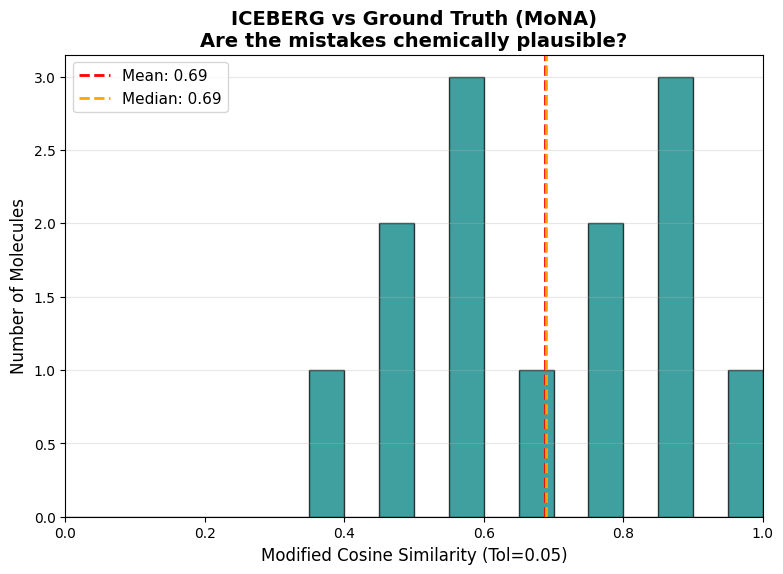

In [11]:
# ==========================================
# 4. RESULTS & VISUALIZATION
# ==========================================
valid_count = len(cosine_scores)
print("\n" + "="*40)
print(f"EVALUATION SUMMARY")
print("="*40)
print(f"Total Predictions Processed: {len(preds_df)}")
print(f"Successfully Scored Pairs:   {valid_count}")
print(f"Skipped (Failed filters):    {skipped_count}")

if valid_count > 0:
    mean_score = np.mean(cosine_scores)
    median_score = np.median(cosine_scores)
    
    print(f"Mean Modified Cosine:        {mean_score:.3f}")
    print(f"Median Modified Cosine:      {median_score:.3f}")

    # Plot the Distribution
    plt.figure(figsize=(9, 6))
    plt.hist(cosine_scores, bins=np.linspace(0, 1, 21), color='teal', edgecolor='black', alpha=0.75)
    
    plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean: {mean_score:.2f}')
    plt.axvline(median_score, color='orange', linestyle='dashed', linewidth=2, 
                label=f'Median: {median_score:.2f}')

    plt.title("ICEBERG vs Ground Truth (MoNA)\nAre the mistakes chemically plausible?", fontsize=14, fontweight='bold')
    plt.xlabel(f"Modified Cosine Similarity (Tol={COSINE_TOLERANCE})", fontsize=12)
    plt.ylabel("Number of Molecules", fontsize=12)
    plt.xlim(0, 1.0)
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    
    # Save the plot
    plot_path = "iceberg_plausible_mistakes_distribution.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to {plot_path}")
    plt.show()
else:
    print("\nNo valid scores to plot. Check if the min_peaks threshold is too strict for the predictions.")